## A vs B Tuned Cells by Mouse (AND max-Rayleigh match)

This notebook uses `tuned_ids_and_max_rayleigh_long.csv` from `tuned_ids_and_max_rayleigh.py` and plots two bars per mouse:
- `A`: cells passing `A_and_maxA` (pre-flip A-tuned AND max-Rayleigh angle is A)
- `B`: cells passing `B_and_maxB` (post-flip B-tuned AND max-Rayleigh angle is B)


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SAVE_ROOT = Path(r"/ceph/branco/Jasmine_Laurence/rayleigh_analysis/Top2_TunED")
CSV_PATH = SAVE_ROOT / "tuned_ids_and_max_rayleigh_long.csv"

MOUSE_ORDER = ["JAL3", "JAL4", "JAL5", "JAL6", "JAL7", "JAL8"]
COND_A = "barrier_pre_flip"
COND_B = "barrier_post_flip"


In [2]:
def session_to_mouse(session: str) -> str:
    m = re.match(r"^(JAL)(\d+)", str(session))
    if not m:
        return "UNKNOWN"
    return f"JAL{int(m.group(2))}"


def load_long_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")
    df = pd.read_csv(path)
    needed = {"session", "condition", "cluster_id", "A_and_maxA", "B_and_maxB"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {sorted(missing)}")

    df["mouse"] = df["session"].map(session_to_mouse)
    df["A_and_maxA"] = df["A_and_maxA"].astype(bool)
    df["B_and_maxB"] = df["B_and_maxB"].astype(bool)
    return df


def build_session_table(df: pd.DataFrame) -> pd.DataFrame:
    # denominator: all cells in that session+condition
    base = (
        df.groupby(["mouse", "session", "condition"], as_index=False)
        .agg(total_cells=("cluster_id", "nunique"), n_A=("A_and_maxA", "sum"), n_B=("B_and_maxB", "sum"))
    )

    # Per-session percentages for A (from pre) and B (from post)
    a_sess = base[base["condition"] == COND_A][["mouse", "session", "total_cells", "n_A"]].copy()
    a_sess["pct_A"] = np.where(a_sess["total_cells"] > 0, a_sess["n_A"] / a_sess["total_cells"], np.nan)

    b_sess = base[base["condition"] == COND_B][["mouse", "session", "total_cells", "n_B"]].copy()
    b_sess["pct_B"] = np.where(b_sess["total_cells"] > 0, b_sess["n_B"] / b_sess["total_cells"], np.nan)

    sess = a_sess.merge(
        b_sess[["mouse", "session", "pct_B"]],
        on=["mouse", "session"],
        how="outer",
    )
    return sess


def pooled_by_mouse(df: pd.DataFrame) -> pd.DataFrame:
    base = (
        df.groupby(["mouse", "condition"], as_index=False)
        .agg(total_cells=("cluster_id", "nunique"), n_A=("A_and_maxA", "sum"), n_B=("B_and_maxB", "sum"))
    )

    a = base[base["condition"] == COND_A][["mouse", "total_cells", "n_A"]].copy()
    a = a.rename(columns={"total_cells": "total_A", "n_A": "count_A"})

    b = base[base["condition"] == COND_B][["mouse", "total_cells", "n_B"]].copy()
    b = b.rename(columns={"total_cells": "total_B", "n_B": "count_B"})

    out = a.merge(b, on="mouse", how="outer")
    out["pct_A"] = np.where(out["total_A"] > 0, out["count_A"] / out["total_A"], 0.0)
    out["pct_B"] = np.where(out["total_B"] > 0, out["count_B"] / out["total_B"], 0.0)

    idx = pd.Index(MOUSE_ORDER, name="mouse")
    out = out.set_index("mouse").reindex(idx).reset_index()
    for c in ["total_A", "count_A", "total_B", "count_B", "pct_A", "pct_B"]:
        out[c] = out[c].fillna(0.0)
    return out


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Pooled percentages by mouse (A vs B):
mouse  count_A  total_A  pct_A_%  count_B  total_B  pct_B_%
 JAL3        0      213 0.000000        0      206 0.000000
 JAL4       12      672 1.785714        8      663 1.206637
 JAL5        1      402 0.248756        0      410 0.000000
 JAL6        8      373 2.144772        7      367 1.907357
 JAL7        9      520 1.730769        9      519 1.734104
 JAL8        7      410 1.707317       11      410 2.682927


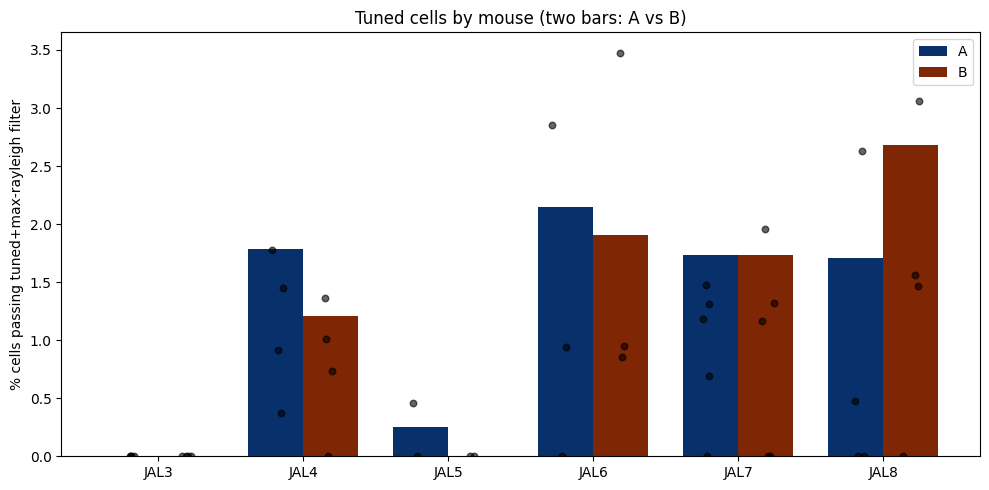

In [6]:
def plot_a_b_by_mouse(mouse_df: pd.DataFrame, session_df: pd.DataFrame):
    x = np.arange(len(MOUSE_ORDER))
    width = 0.38

    a_vals = mouse_df["pct_A"].to_numpy() * 100
    b_vals = mouse_df["pct_B"].to_numpy() * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, a_vals, width, label="A", color="#08306B")
    ax.bar(x + width / 2, b_vals, width, label="B", color="#7F2704")

    # Session-level overlays
    sess = session_df[session_df["mouse"].isin(MOUSE_ORDER)].copy()
    sess["mouse_idx"] = sess["mouse"].map({m: i for i, m in enumerate(MOUSE_ORDER)})
    rng = np.random.default_rng(0)

    sub_a = sess.dropna(subset=["pct_A"])
    if not sub_a.empty:
        jit = rng.normal(0, 0.04, size=len(sub_a))
        xs = sub_a["mouse_idx"].to_numpy() - width / 2 + jit
        ys = sub_a["pct_A"].to_numpy() * 100
        ax.scatter(xs, ys, s=22, alpha=0.6, color="black")

    sub_b = sess.dropna(subset=["pct_B"])
    if not sub_b.empty:
        jit = rng.normal(0, 0.04, size=len(sub_b))
        xs = sub_b["mouse_idx"].to_numpy() + width / 2 + jit
        ys = sub_b["pct_B"].to_numpy() * 100
        ax.scatter(xs, ys, s=22, alpha=0.6, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(MOUSE_ORDER)
    ax.set_ylabel("% cells passing tuned+max-rayleigh filter")
    ax.set_title("Tuned cells by mouse (two bars: A vs B)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("/ceph/branco/Laurence/thesis/efizz_chapter/barrier_cell_counts.eps")
    plt.show()


df = load_long_table(CSV_PATH)
mouse_df = pooled_by_mouse(df)
session_df = build_session_table(df)

pretty = mouse_df.copy()
pretty["pct_A_%"] = pretty["pct_A"] * 100
pretty["pct_B_%"] = pretty["pct_B"] * 100
print("Pooled percentages by mouse (A vs B):")
print(pretty[["mouse", "count_A", "total_A", "pct_A_%", "count_B", "total_B", "pct_B_%"]].to_string(index=False))

plot_a_b_by_mouse(mouse_df, session_df)


